# GMT RAPL Energy Analysis
**Blender Windows Benchmark – CPU Energy Measurements**

This notebook loads GMT export CSVs and visualizes RAPL energy data per phase and domain.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import glob
import os

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
PALETTE = {"cpu_package": "#378ADD", "cpu_cores": "#1D9E75", "psys": "#D85A30"}
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300, "figure.figsize": (10, 5)})


## Load data

In [2]:
#new load 
RUN_INDEX = -1  # -1 = neuester, -2 = vorletzter

EXPORT_DIR = Path("exports/")

# Alle verfügbaren Run-IDs aus meta-Dateien ermitteln
meta_files = sorted(EXPORT_DIR.glob("*_meta.csv"))
run_ids = [f.stem.replace("_meta", "") for f in meta_files]

print("Verfügbare Runs:")
for i, rid in enumerate(run_ids):
    meta = pd.read_csv(EXPORT_DIR / f"{rid}_meta.csv")
    print(f"  [{i - len(run_ids)}] {rid[:8]}... – {meta['name'].iloc[0]}")

run_id = run_ids[RUN_INDEX]
print(f"\nLade: {run_id[:8]}...")

df_phase = pd.read_csv(EXPORT_DIR / f"{run_id}_phase_stats.csv")
df_meas  = pd.read_csv(EXPORT_DIR / f"{run_id}_measurements.csv")
df_meta  = pd.read_csv(EXPORT_DIR / f"{run_id}_meta.csv")

notes_path = EXPORT_DIR / f"{run_id}_notes.csv"
df_notes = pd.read_csv(notes_path) if notes_path.exists() else None

run_name = df_meta["name"].iloc[0]
duration = round(df_meta["duration_seconds"].iloc[0], 1)
print(f"Run: {run_name}")
print(f"Duration: {duration}s")
print(f"Notes: {'ja' if df_notes is not None else 'nicht vorhanden – alten Run neu exportieren'}")

Verfügbare Runs:
  [-2] 72013d81... – Run 2026-04-19 14:37:55.615711
  [-1] f52168a3... – Run 2026-04-20 12:28:41.092629

Lade: f52168a3...
Run: Run 2026-04-20 12:28:41.092629
Duration: 747.3s
Notes: ja


## Phase stats overview

In [3]:
rapl_energy = df_phase[
    df_phase["metric"].str.contains("energy_rapl") &
    (df_phase["type"] == "TOTAL")
].copy()

rapl_energy["value_wh"] = rapl_energy["value"] / 3_600_000_000

# Alle Phasen, Pivot
table = rapl_energy.pivot_table(
    index="phase", columns="detail_name", values="value_wh"
).round(4)

table.columns.name = None
table.index.name = None

# Präfix (000_, 001_ etc.) entfernen
table.index = table.index.str.replace(r'^\d+_', '', regex=True)
# Eckige Klammern entfernen
table.index = table.index.str.replace(r'[\[\]]', '', regex=True)
# Unterstriche escapen
table.index = table.index.str.replace('_', r'\_', regex=False)

table = table.rename(columns={
    "cpu_cores":   "CPU Cores (Wh)",
    "cpu_package": "CPU Package (Wh)",
    "psys":        "System (Wh)"
})

# Summenzeile
table.loc["\\textbf{Total}"] = table.sum()

print(table.to_latex(
    caption="RAPL energy consumption per phase – Blender Cycles CPU render (Lone Monk, 64 spp)",
    label="tab:rapl_energy_phases",
    float_format="%.4f",
    bold_rows=True,
    position="h",
    escape=False  # wichtig wegen \textbf in index
))

\begin{table}[h]
\caption{RAPL energy consumption per phase – Blender Cycles CPU render (Lone Monk, 64 spp)}
\label{tab:rapl_energy_phases}
\begin{tabular}{lrrr}
\toprule
 & CPU Cores (Wh) & CPU Package (Wh) & System (Wh) \\
\midrule
\textbf{BASELINE} & 0.0509 & 0.1109 & 0.2714 \\
\textbf{INSTALLATION} & 0.2687 & 0.5335 & 1.2584 \\
\textbf{BOOT} & 0.0038 & 0.0054 & 0.0096 \\
\textbf{IDLE} & 0.0632 & 0.1299 & 0.2979 \\
\textbf{RUNTIME} & 1.2690 & 1.6438 & 2.8170 \\
\textbf{Blender Render} & 1.2690 & 1.6438 & 2.8170 \\
\textbf{REMOVE} & 0.0035 & 0.0051 & 0.0091 \\
\textbf{\textbf{Total}} & 2.9281 & 4.0724 & 7.4804 \\
\bottomrule
\end{tabular}
\end{table}



## Energy per domain (render phase)

/tmp/ipykernel_14463/3378099561.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


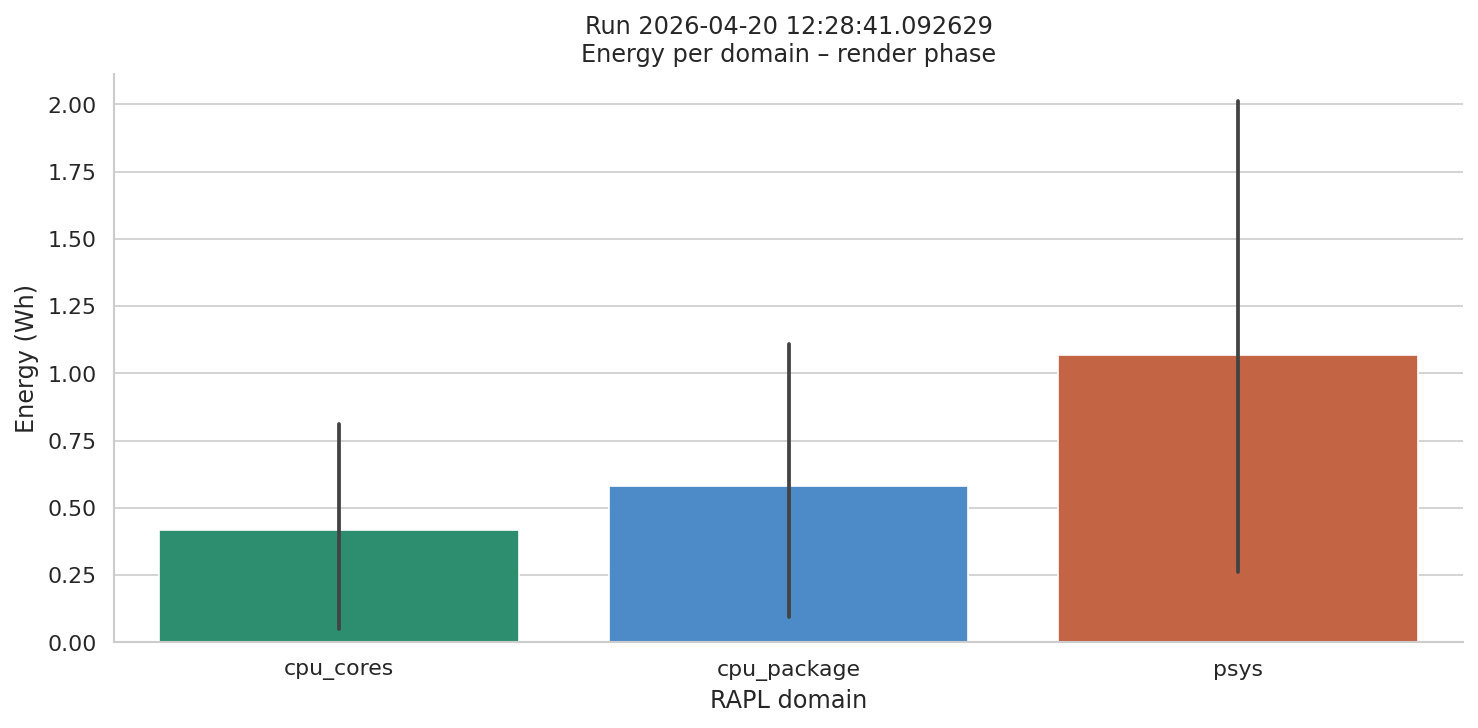

In [4]:
render = rapl_energy[~rapl_energy["phase"].str.startswith("[")].copy()

fig, ax = plt.subplots()
sns.barplot(
    data=render,
    x="detail_name", y="value_wh",
    palette=PALETTE, ax=ax
)
ax.set_xlabel("RAPL domain")
ax.set_ylabel("Energy (Wh)")
ax.set_title(f"{run_name}\nEnergy per domain – render phase")
sns.despine()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "energy_per_domain.png", bbox_inches="tight")
plt.show()


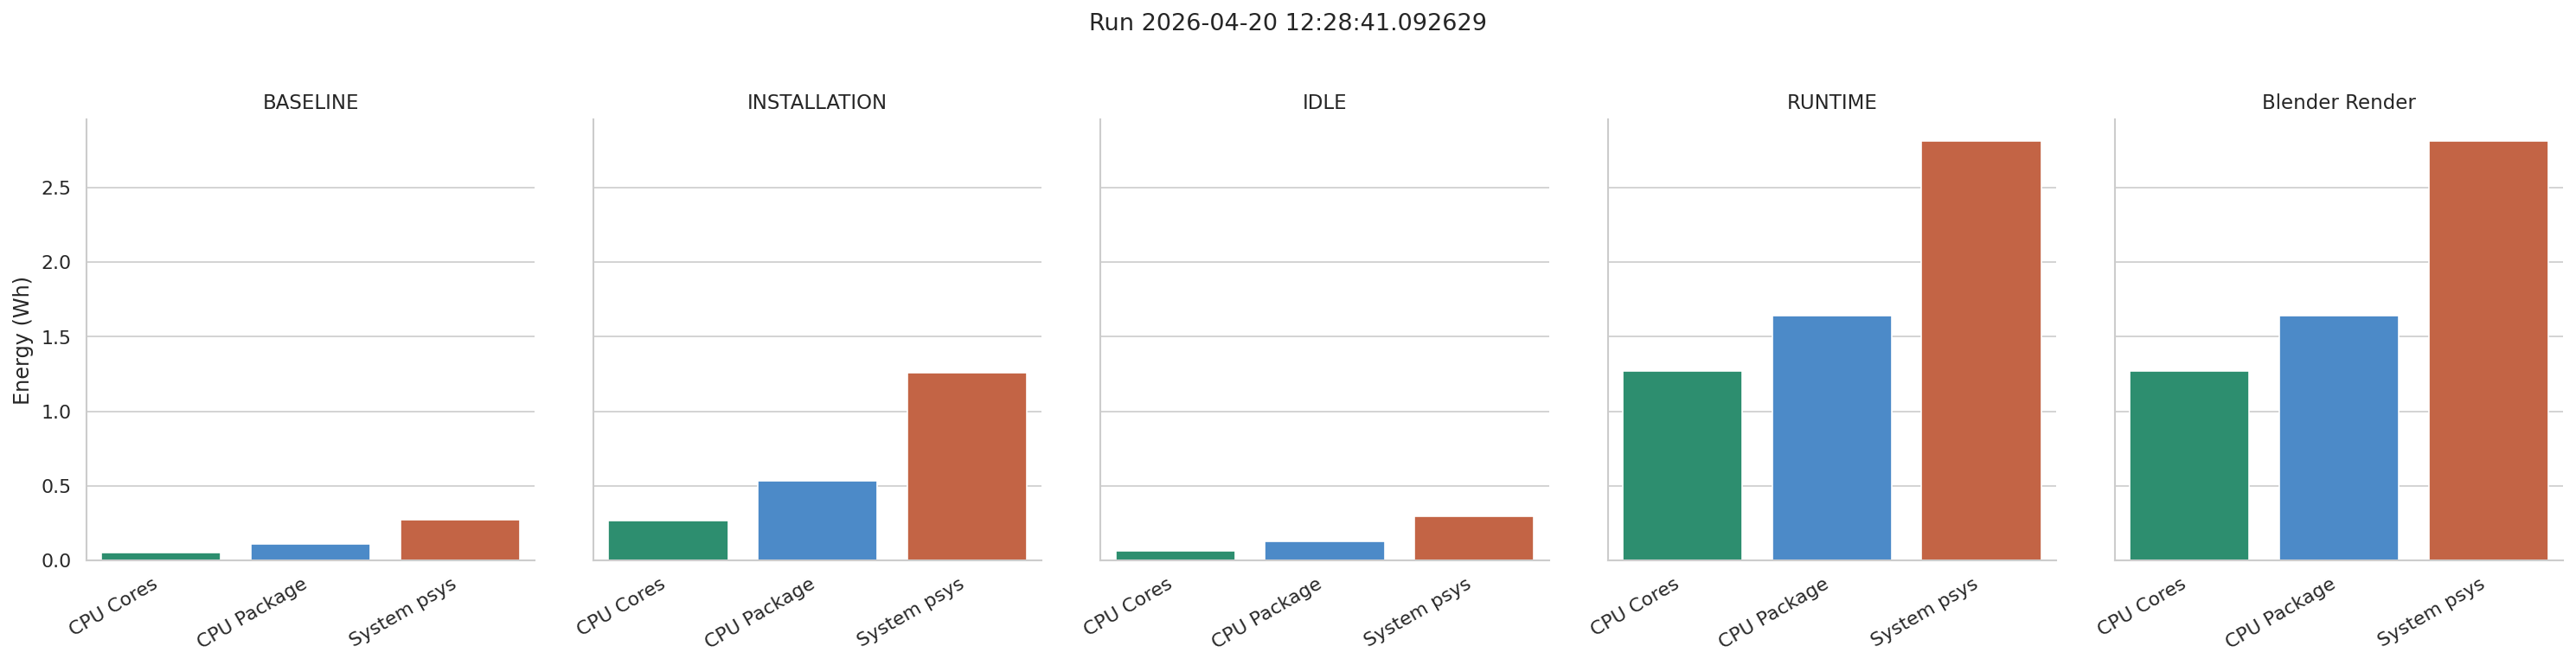

In [5]:
rapl_energy = df_phase[
    df_phase["metric"].str.contains("energy_rapl") &
    (df_phase["type"] == "TOTAL")
].copy()
rapl_energy["value_wh"] = rapl_energy["value"] / 3_600_000_000
rapl_energy["phase_clean"] = rapl_energy["phase"].str.replace(r'^\d+_', '', regex=True)
rapl_energy["phase_clean"] = rapl_energy["phase_clean"].str.replace(r'[\[\]]', '', regex=True)


phase_order = [
    p for p in rapl_energy["phase_clean"].unique()
    if rapl_energy[rapl_energy["phase_clean"] == p]["value_wh"].max() >= 0.05
]
fig, axes = plt.subplots(1, len(phase_order), figsize=(4 * len(phase_order), 5), sharey=True)
if len(phase_order) == 1:
    axes = [axes]

for ax, phase in zip(axes, phase_order):
    data = rapl_energy[rapl_energy["phase_clean"] == phase]
    sns.barplot(
    data=data,
    x="detail_name", y="value_wh",
    hue="detail_name", palette=PALETTE,
    legend=False, ax=ax,
    errorbar=None,
    order=["cpu_cores", "cpu_package", "psys"]
)
    ax.set_title(phase, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Energy (Wh)" if ax == axes[0] else "")
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["CPU Cores", "CPU Package", "System psys"], rotation=30, ha="right")
    sns.despine(ax=ax)

fig.suptitle(f"{run_name}", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(EXPORT_DIR / "plots" / "energy_per_phase_domains.png", bbox_inches="tight", dpi=300)
plt.show()

In [6]:
baseline = rapl_energy[rapl_energy["phase_clean"] == "BASELINE"].set_index("detail_name")["value_wh"]
render = rapl_energy[rapl_energy["phase_clean"] == "Blender Render"].set_index("detail_name")["value_wh"]
netto = render - baseline
print(netto)  # reiner Blender-Verbrauch ohne System-Idle

detail_name
cpu_cores      1.218118
cpu_package    1.532876
psys           2.545617
Name: value_wh, dtype: float64


In [8]:
baseline_duration_s = 60  # GMT BASELINE Phase ist immer 60s

render_duration_s = df_notes[
    (df_notes["phase"] == "Blender Render") & 
    (df_notes["event"] == "start")
]["duration_seconds"].iloc[0]

print(f"Render-Dauer: {render_duration_s:.1f}s")

baseline = rapl_energy[rapl_energy["phase_clean"] == "BASELINE"].set_index("detail_name")["value_wh"]
render   = rapl_energy[rapl_energy["phase_clean"] == "Blender Render"].set_index("detail_name")["value_wh"]

netto = render - baseline * (render_duration_s / baseline_duration_s)

print("\nNetto:")
print(netto)

Render-Dauer: 333.5s

Netto:
detail_name
cpu_cores      0.986184
cpu_package    1.027360
psys           1.308607
Name: value_wh, dtype: float64


In [9]:
# Render-Dauer aus notes
render_row = df_notes[df_notes["phase"].str.contains("Blender")]
print(df_notes)  # zeig alle Phasen mit Zeiten

                                      note              time  event  \
0                Starting phase [BASELINE]  1776680934364308  start   
1                Starting phase [BASELINE]  1776680934364308  start   
2       Ending phase [BASELINE] [UNPADDED]  1776680994364793    end   
3       Ending phase [BASELINE] [UNPADDED]  1776680994364793    end   
4         Ending phase [BASELINE] [PADDED]  1776680994463793    end   
5         Ending phase [BASELINE] [PADDED]  1776680994463793    end   
6            Starting phase [INSTALLATION]  1776680995464528  start   
7            Starting phase [INSTALLATION]  1776680995464528  start   
8   Ending phase [INSTALLATION] [UNPADDED]  1776681264735135    end   
9   Ending phase [INSTALLATION] [UNPADDED]  1776681264735135    end   
10    Ending phase [INSTALLATION] [PADDED]  1776681264834135    end   
11    Ending phase [INSTALLATION] [PADDED]  1776681264834135    end   
12                   Starting phase [BOOT]  1776681265920234  start   
13    

In [10]:
render_start = df_notes[(df_notes["phase"] == "Blender Render") & 
                         (df_notes["event"] == "start")]["time"].iloc[0]
render_end   = df_notes[(df_notes["phase"] == "Blender Render") & 
                         (df_notes["event"] == "end")]["time"].iloc[0]
render_duration_s = (render_end - render_start) / 1e6

# Oder direkt aus der duration_seconds Spalte:
render_duration_s = df_notes[df_notes["phase"] == "Blender Render"]["duration_seconds"].iloc[0]
print(f"Render-Dauer: {render_duration_s:.1f}s")

Render-Dauer: 333.5s


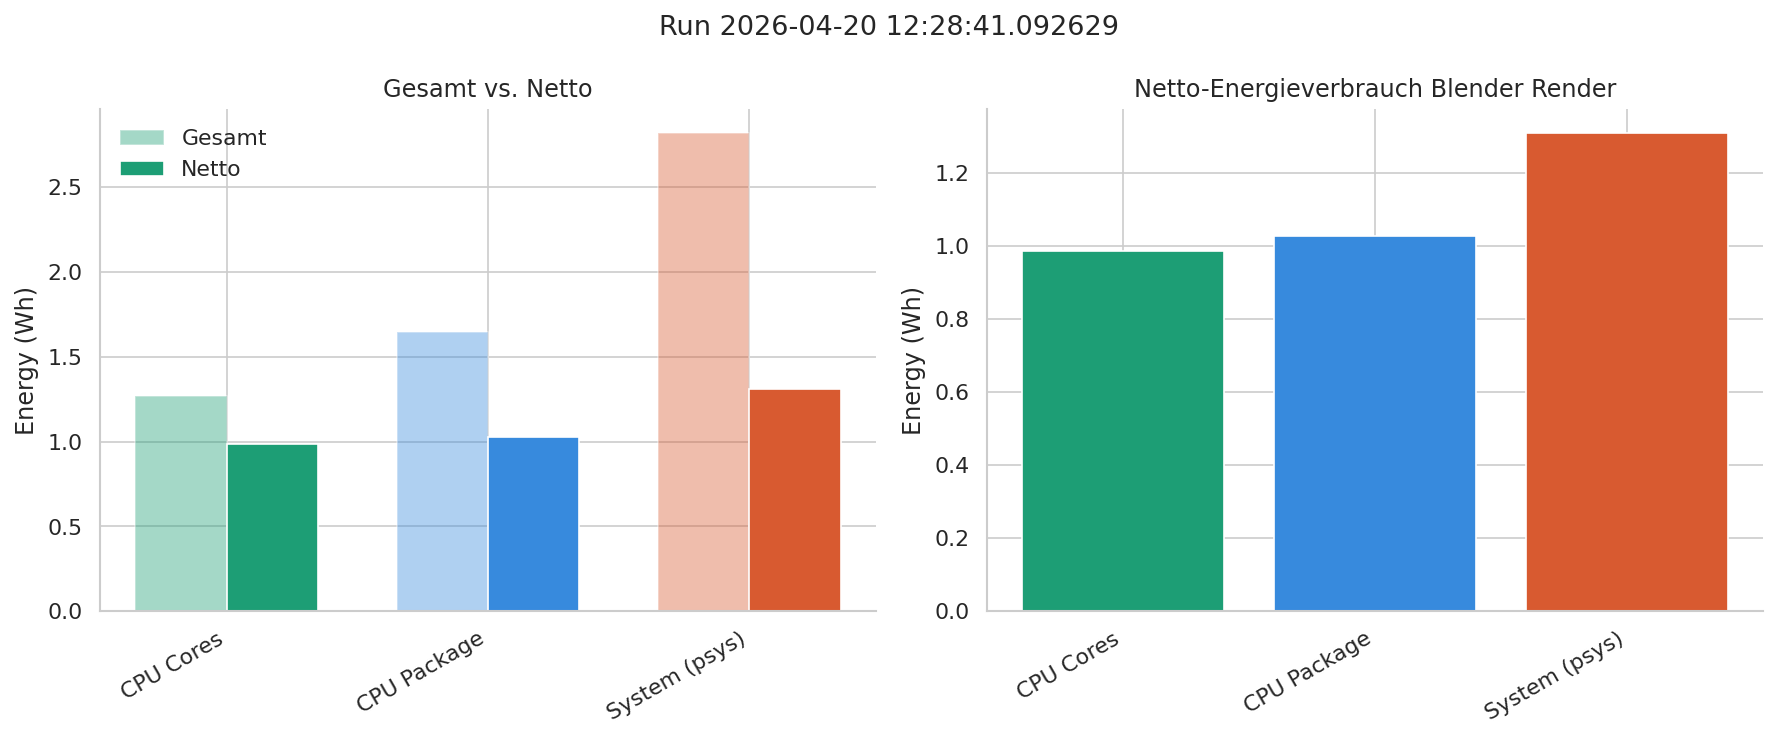


Netto-Energieverbrauch:
  CPU Cores            0.9862 Wh
  CPU Package          1.0274 Wh
  System (psys)        1.3086 Wh


In [21]:
# Baseline auf Render-Dauer skalieren
baseline_duration_s = 60
render_duration_s = df_notes[
    (df_notes["phase"] == "Blender Render") &
    (df_notes["event"] == "start")
]["duration_seconds"].iloc[0]

baseline = rapl_energy[rapl_energy["phase_clean"] == "BASELINE"].set_index("detail_name")["value_wh"]
render   = rapl_energy[rapl_energy["phase_clean"] == "Blender Render"].set_index("detail_name")["value_wh"]

netto = render - baseline * (render_duration_s / baseline_duration_s)  # ← render_duration_s

domains = ["cpu_cores", "cpu_package", "psys"]
labels  = ["CPU Cores", "CPU Package", "System (psys)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Links: Gesamt vs Netto
ax = axes[0]
x = range(len(domains))
width = 0.35
ax.bar([i - width/2 for i in x], [render[d] for d in domains],
       width, label="Gesamt", color=[PALETTE[d] for d in domains], alpha=0.4)
ax.bar([i + width/2 for i in x], [netto[d] for d in domains],
       width, label="Netto", color=[PALETTE[d] for d in domains], alpha=1.0)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("Energy (Wh)")
ax.set_title("Gesamt vs. Netto")
ax.legend(frameon=False)
sns.despine(ax=ax)

# Rechts: Nur Netto
ax = axes[1]
ax.bar(list(x), [netto[d] for d in domains],
       color=[PALETTE[d] for d in domains], alpha=1.0)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("Energy (Wh)")
ax.set_title("Netto-Energieverbrauch Blender Render")
sns.despine(ax=ax)

fig.suptitle(f"{run_name}", fontsize=13)
plt.tight_layout()
plt.savefig(EXPORT_DIR / "plots" / "energy_netto.png", bbox_inches="tight", dpi=300)
plt.show()

print("\nNetto-Energieverbrauch:")
for d, l in zip(domains, labels):
    print(f"  {l:<20} {netto[d]:.4f} Wh")

## 4. Zeitreihe analysieren

In [22]:
 
# Renderzeit aus meta holen
render_duration = df_meta["duration_seconds"].iloc[0]
render["power_w"] = render / (render_duration / 3600)

In [23]:
# Leistungsverlauf: gibt es Warmup-Effekte? Throttling?
rapl_meas = df_meas[df_meas["metric"].str.contains("energy_rapl")].copy()
rapl_meas["power_w"] = rapl_meas["value"] / 1e6 / 0.099
# Anfang vs Ende vergleichen
print(rapl_meas.groupby("detail_name")["power_w"].describe())

              count       mean       std        min        25%        50%  \
detail_name                                                                 
cpu_cores    6852.0   8.964145  6.685564   0.350172   2.193255  10.152172   
cpu_package  6852.0  13.175130  7.078903   3.221293   6.079157  14.796707   
psys         6852.0  25.371024  9.191092  11.544273  16.198199  27.743556   

                   75%        max  
detail_name                        
cpu_cores    14.311048  31.426323  
cpu_package  18.802833  37.185818  
psys         32.556856  57.985859  


## Power over time (raw measurements)

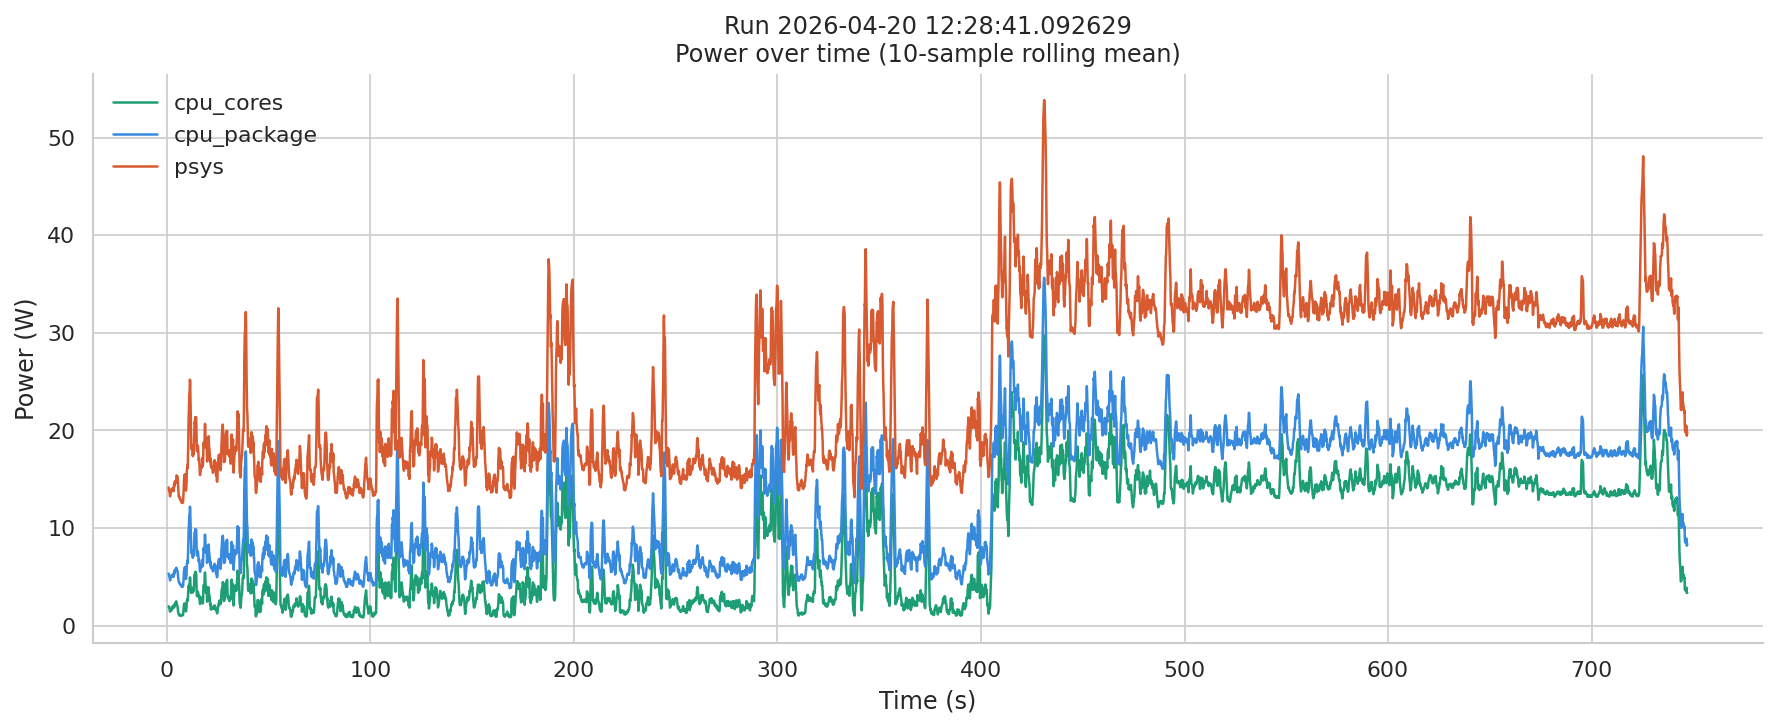

In [24]:
rapl_meas = df_meas[df_meas["metric"].str.contains("energy_rapl")].copy()

# Convert timestamp to relative seconds
rapl_meas["timestamp"] = pd.to_datetime(rapl_meas["timestamp"], utc=True)
t0 = rapl_meas["timestamp"].min()
rapl_meas["t_sec"] = (rapl_meas["timestamp"] - t0).dt.total_seconds()

# uJ per interval → mW  (interval ~99ms = 0.099s)
rapl_meas["power_w"] = rapl_meas["value"] / 1e6 / 0.099

fig, ax = plt.subplots(figsize=(12, 5))
for domain, grp in rapl_meas.groupby("detail_name"):
    ax.plot(grp["t_sec"], grp["power_w"].rolling(10).mean(),
            label=domain, color=PALETTE.get(domain, "gray"), linewidth=1.2)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (W)")
ax.set_title(f"{run_name}\nPower over time (10-sample rolling mean)")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "power_over_time.png", bbox_inches="tight")
plt.show()


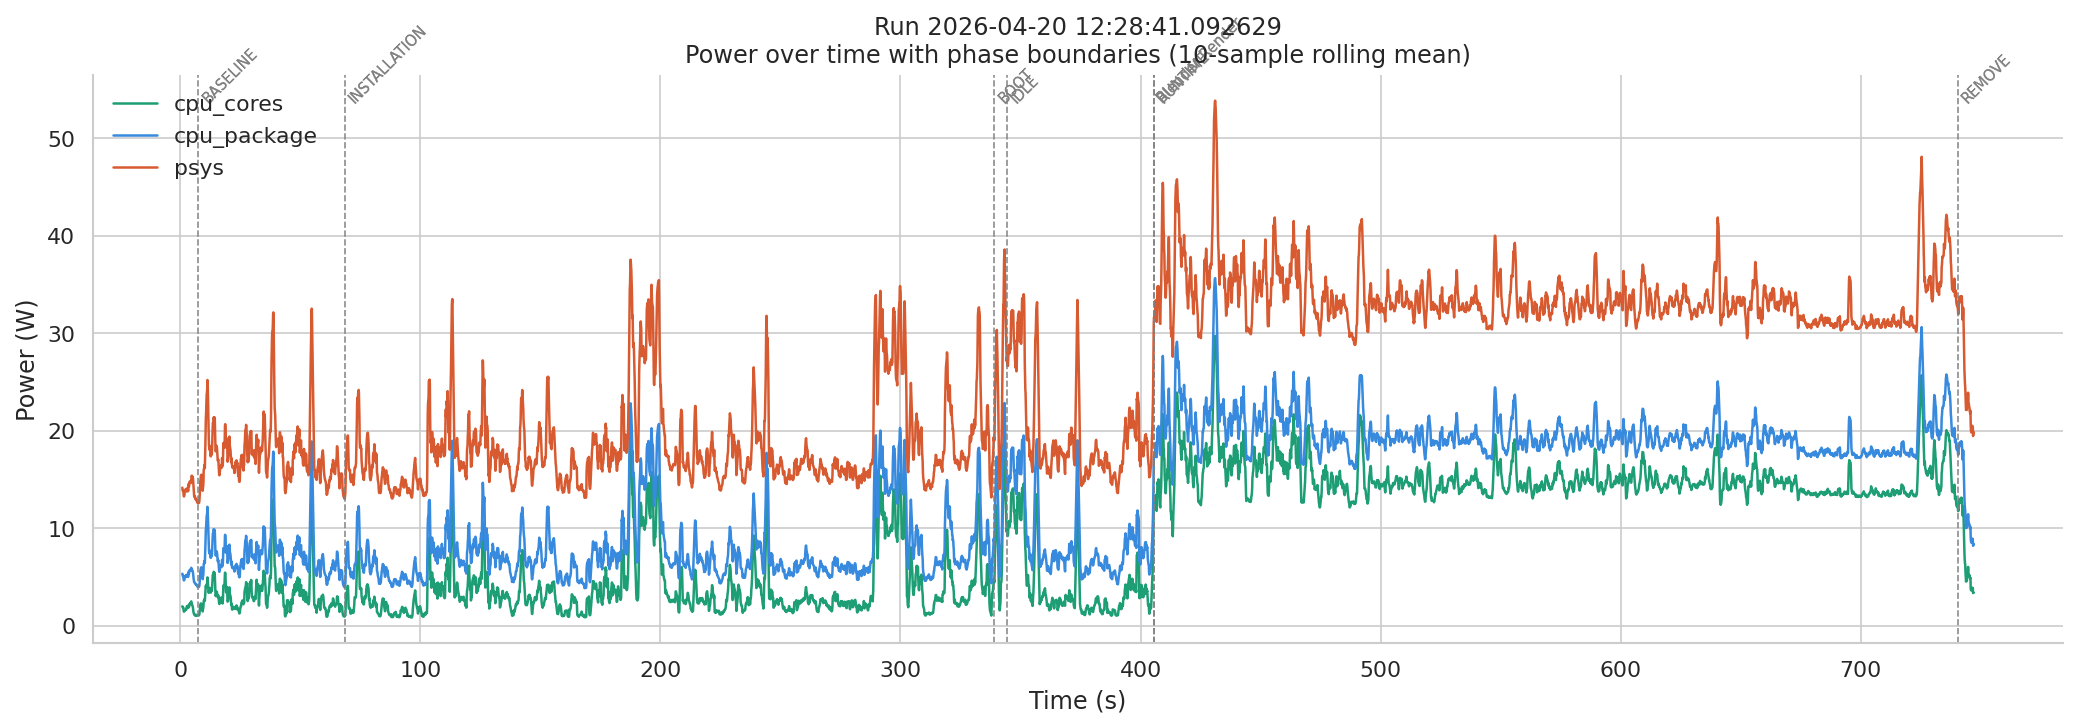

In [27]:
# Notes laden
notes_files = sorted(EXPORT_DIR.glob("*_notes.csv"))
df_notes = pd.read_csv(notes_files[RUN_INDEX])

rapl_meas = df_meas[df_meas["metric"].str.contains("energy_rapl")].copy()
rapl_meas["timestamp"] = pd.to_datetime(rapl_meas["timestamp"], utc=True)
t0 = rapl_meas["timestamp"].min()
rapl_meas["t_sec"] = (rapl_meas["timestamp"] - t0).dt.total_seconds()
rapl_meas["power_w"] = rapl_meas["value"] / 1e6 / 0.099

# Phasengrenzen aus notes berechnen
df_notes["timestamp"] = pd.to_numeric(df_notes["time"])
t0_rapl_us = rapl_meas["timestamp"].min().timestamp() * 1e6
df_notes["t_sec_plot"] = (df_notes["timestamp"] - t0_rapl_us) / 1e6

# Nur Start-Events
starts_only = df_notes[df_notes["event"] == "start"]

fig, ax = plt.subplots(figsize=(14, 5))

# Power Linien
for domain, grp in rapl_meas.groupby("detail_name"):
    ax.plot(grp["t_sec"], grp["power_w"].rolling(10).mean(),
            label=domain, color=PALETTE.get(domain, "gray"), linewidth=1.2)

# Phasengrenzen einzeichnen
for _, row in starts_only.iterrows():
    ax.axvline(x=row["t_sec_plot"], color="gray", linestyle="--",
               linewidth=0.8, alpha=0.6)
    ax.text(row["t_sec_plot"] + 0.5, ax.get_ylim()[1] * 0.95,
            row["phase"], fontsize=7, color="gray", rotation=45, ha="left")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (W)")
ax.set_title(f"{run_name}\nPower over time with phase boundaries (10-sample rolling mean)")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "plots" / "power_over_time_phases.png", bbox_inches="tight", dpi=300)
plt.show()

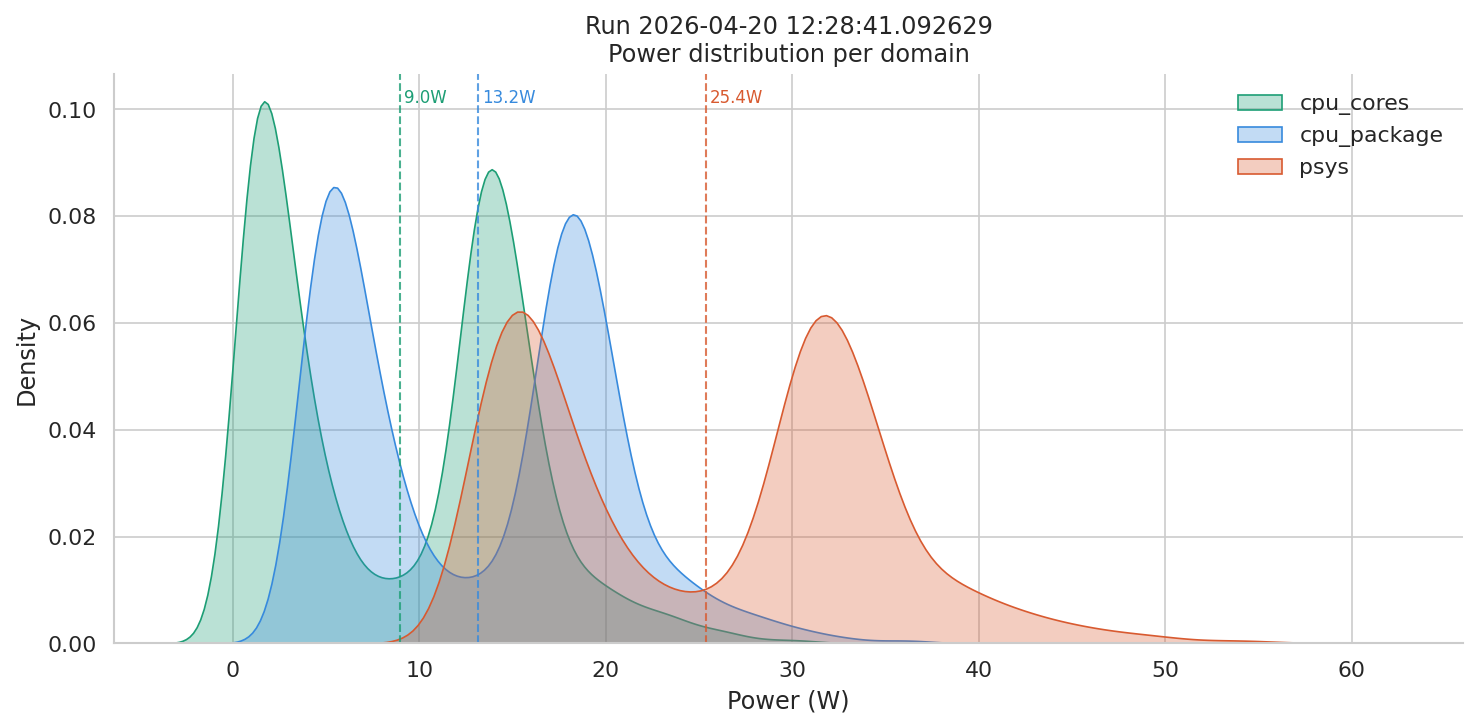

In [31]:
#verteilung 


fig, ax = plt.subplots(figsize=(10, 5))
for domain, grp in rapl_meas.groupby("detail_name"):
    sns.kdeplot(grp["power_w"], label=domain, ax=ax,
                color=PALETTE.get(domain), fill=True, alpha=0.3)
    # Mittelwert als vertikale Linie
    mean = grp["power_w"].mean()
    ax.axvline(mean, color=PALETTE.get(domain), linestyle="--", 
               linewidth=1, alpha=0.8)
    ax.text(mean + 0.2, ax.get_ylim()[1] * 0.95, 
            f"{mean:.1f}W", fontsize=8, color=PALETTE.get(domain))

ax.set_xlabel("Power (W)")
ax.set_title(f"{run_name}\nPower distribution per domain")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "plots" / "power_distribution.png", bbox_inches="tight", dpi=300)
plt.show()

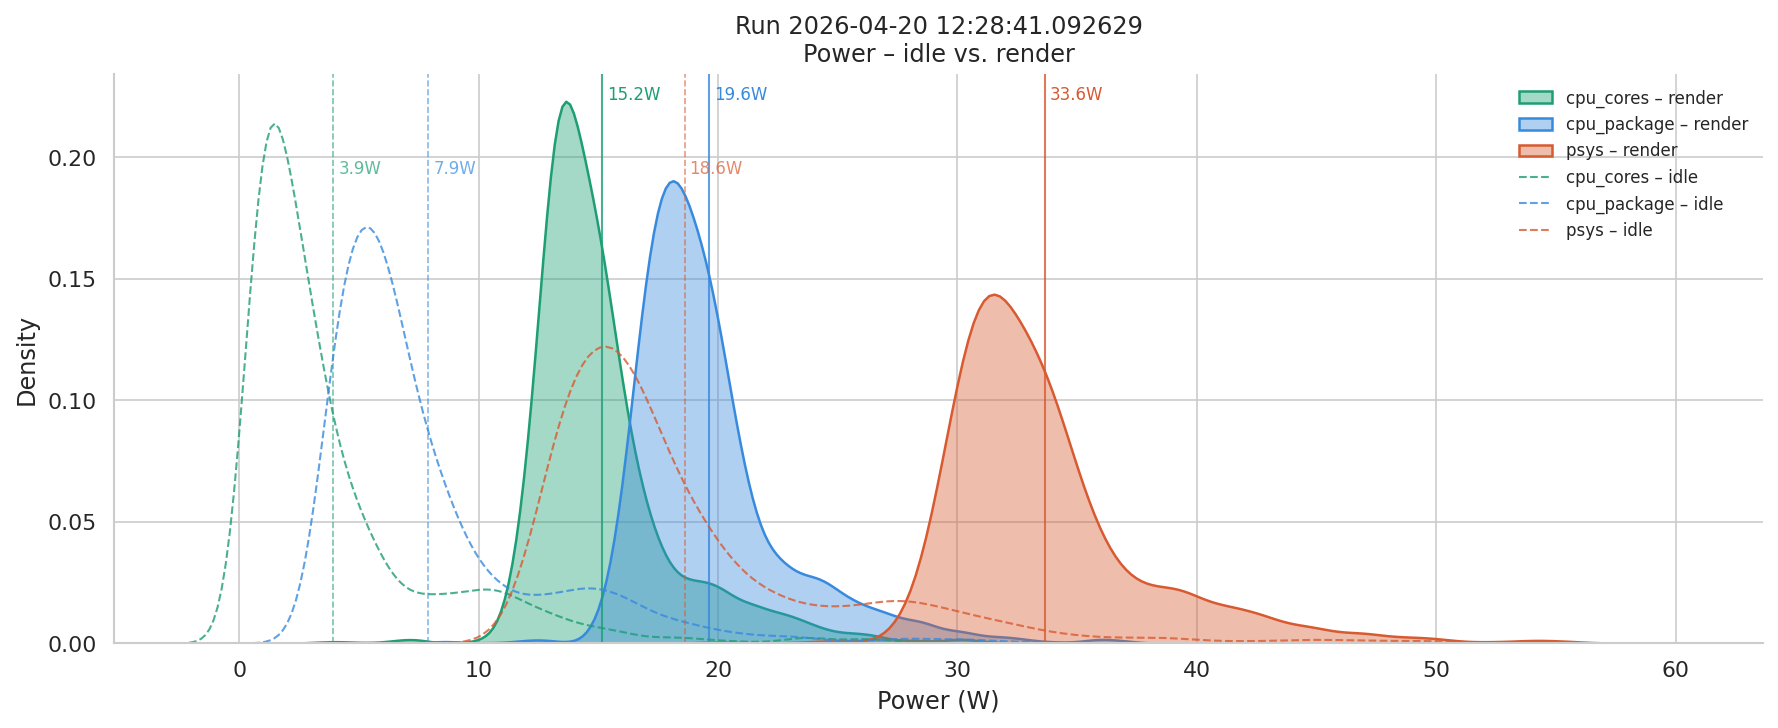

In [40]:
render_start = starts_only[starts_only["phase"] == "Blender Render"]["t_sec_plot"].iloc[0]
render_end   = df_notes[(df_notes["phase"] == "Blender Render") & 
                         (df_notes["event"] == "end")]["t_sec_plot"].iloc[0]

rapl_baseline = rapl_meas[rapl_meas["t_sec"] < render_start].copy()
rapl_render   = rapl_meas[
    (rapl_meas["t_sec"] >= render_start) & 
    (rapl_meas["t_sec"] <= render_end)
].copy()

fig, ax = plt.subplots(figsize=(12, 5))

for domain, grp in rapl_render.groupby("detail_name"):
    mean = grp["power_w"].mean()
    sns.kdeplot(grp["power_w"], label=f"{domain} – render", ax=ax,
                color=PALETTE.get(domain), fill=True, alpha=0.4, linewidth=1.2)
    ax.axvline(mean, color=PALETTE.get(domain), linestyle="-",
               linewidth=1, alpha=0.8)
    ax.text(mean + 0.2, ax.get_ylim()[1] * 0.98,
            f"{mean:.1f}W", fontsize=8, color=PALETTE.get(domain),
            va="top", ha="left")

for domain, grp in rapl_baseline.groupby("detail_name"):
    mean = grp["power_w"].mean()
    sns.kdeplot(grp["power_w"], label=f"{domain} – idle", ax=ax,
                color=PALETTE.get(domain), fill=False, alpha=0.8,
                linewidth=1, linestyle="--")
    ax.axvline(mean, color=PALETTE.get(domain), linestyle="--",
               linewidth=0.8, alpha=0.6)
    ax.text(mean + 0.2, ax.get_ylim()[1] * 0.85,
            f"{mean:.1f}W", fontsize=8, color=PALETTE.get(domain),
            va="top", ha="left", alpha=0.7)

ax.set_xlabel("Power (W)")
ax.set_ylabel("Density")
ax.set_title(f"{run_name}\nPower – idle vs. render")
ax.legend(frameon=False, fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "plots" / "power_distribution.png", bbox_inches="tight", dpi=300)
plt.show()

/tmp/ipykernel_14463/481004649.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_list, patch_artist=True, labels=["CPU Cores", "CPU Package", "System"])


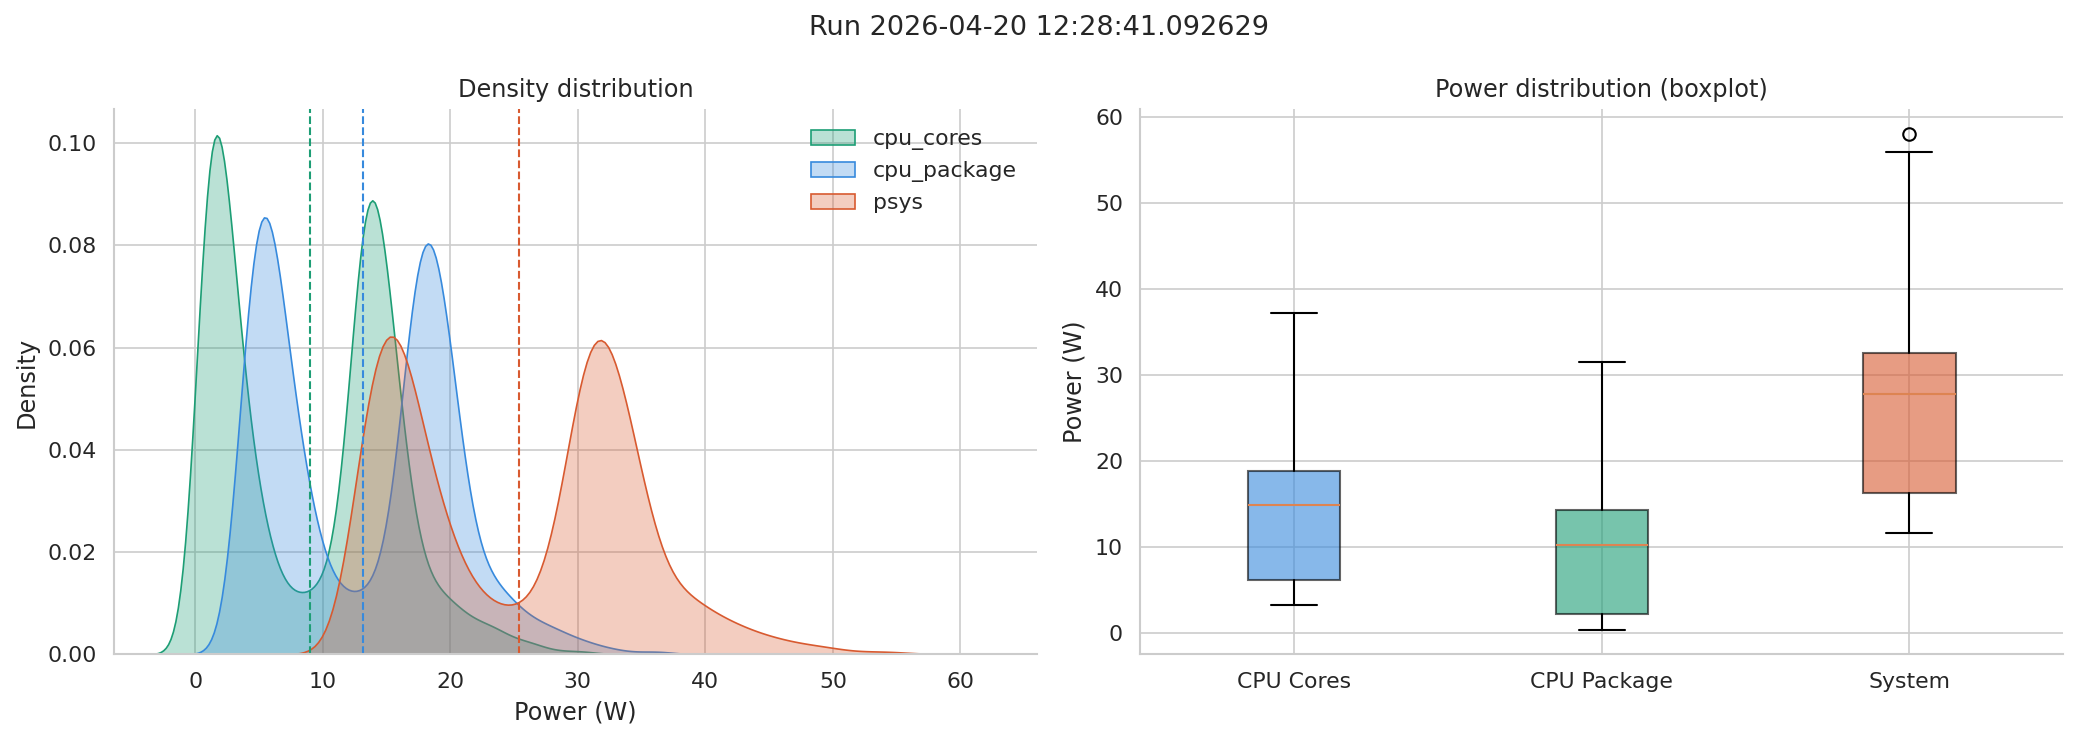

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE links
ax = axes[0]
for domain, grp in rapl_meas.groupby("detail_name"):
    sns.kdeplot(grp["power_w"], label=domain, ax=ax,
                color=PALETTE.get(domain), fill=True, alpha=0.3)
    mean = grp["power_w"].mean()
    ax.axvline(mean, color=PALETTE.get(domain), linestyle="--", linewidth=1)
ax.set_xlabel("Power (W)")
ax.set_title("Density distribution")
ax.legend(frameon=False)
sns.despine(ax=ax)

# Boxplot rechts
ax = axes[1]
domains = rapl_meas["detail_name"].unique()
data_list = [rapl_meas[rapl_meas["detail_name"] == d]["power_w"].dropna() for d in domains]
bp = ax.boxplot(data_list, patch_artist=True, labels=["CPU Cores", "CPU Package", "System"])
for patch, domain in zip(bp["boxes"], domains):
    patch.set_facecolor(PALETTE.get(domain, "gray"))
    patch.set_alpha(0.6)
ax.set_ylabel("Power (W)")
ax.set_title("Power distribution (boxplot)")
sns.despine(ax=ax)

fig.suptitle(f"{run_name}", fontsize=13)
plt.tight_layout()
plt.savefig(EXPORT_DIR / "plots" / "power_distribution_combined.png", bbox_inches="tight", dpi=300)
plt.show()

In [18]:
from scipy import stats

print("Shapiro-Wilk Normalverteilungstest:")
print(f"{'Domain':<15} {'W-Statistik':>12} {'p-Wert':>10} {'Normal?':>10}")
print("-" * 50)
for domain, grp in rapl_meas.groupby("detail_name"):
    sample = grp["power_w"].dropna().sample(min(5000, len(grp)), random_state=42)
    stat, p = stats.shapiro(sample)
    normal = "ja" if p > 0.05 else "nein"
    print(f"{domain:<15} {stat:>12.4f} {p:>10.4f} {normal:>10}")

Shapiro-Wilk Normalverteilungstest:
Domain           W-Statistik     p-Wert    Normal?
--------------------------------------------------
cpu_cores             0.8932     0.0000       nein
cpu_package           0.9080     0.0000       nein
psys                  0.9155     0.0000       nein


## Energy per phase comparison (all phases)

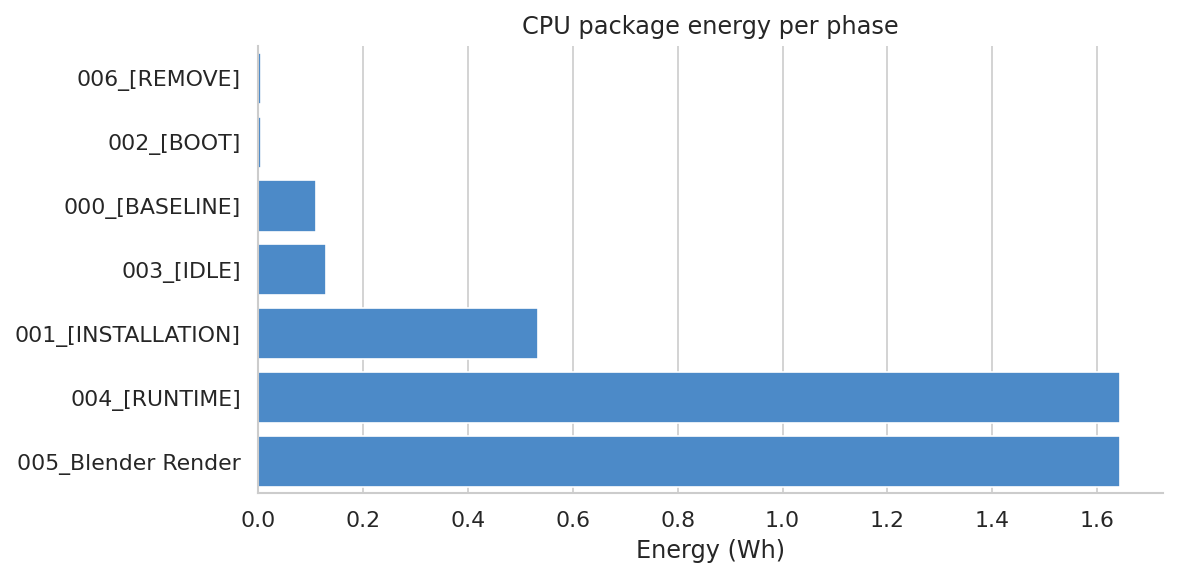

In [20]:
all_phases = rapl_energy[rapl_energy["detail_name"] == "cpu_package"].copy()
all_phases = all_phases.sort_values("value_wh")

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=all_phases, y="phase", x="value_wh",
            color="#378ADD", ax=ax)
ax.set_xlabel("Energy (Wh)")
ax.set_ylabel("")
ax.set_title("CPU package energy per phase")
sns.despine()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "energy_per_phase.png", bbox_inches="tight")
plt.show()


## Sampling rate check

In [38]:
sr = df_phase[df_phase["metric"].str.contains("energy_rapl")][
    ["detail_name","sampling_rate_avg","sampling_rate_95p","sampling_rate_max"]
].drop_duplicates()

print("Sampling rate (ms):")
print(sr.to_string(index=False))


Sampling rate (ms):
detail_name  sampling_rate_avg  sampling_rate_95p  sampling_rate_max
  cpu_cores           108486.0           110587.0           118792.0
cpu_package           108486.0           110580.0           118783.0
       psys           108486.0           110547.0           118777.0
  cpu_cores           108979.0           110628.0           137279.0
cpu_package           108979.0           110608.0           137297.0
       psys           108979.0           110634.0           137205.0
  cpu_cores            98783.0            99186.0            99212.0
cpu_package            98777.0            99184.0            99222.0
       psys            98787.0            99177.0            99180.0
  cpu_cores           109014.0           110649.0           130727.0
cpu_package           109014.0           110641.0           130813.0
       psys           109014.0           110676.0           130870.0
  cpu_cores           109565.0           112216.0           137563.0
cpu_package   